In [1]:
import numpy as np
import matplotlib.pyplot as plt
from polychrom.hdf5_format import list_URIs, load_URI
import noctiluca as nl
import pandas as pd
import tqdm

from matplotlib import rcParams
%config InlineBackend.figure_format='retina'

def get_msd_plateau(dataset):
    return 2*np.nanmean(np.concatenate([np.sum(np.square(np.array(traj)), 1) for traj in dataset]))


/mnt/md0/jjusuf/miniconda3/envs/polysim/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


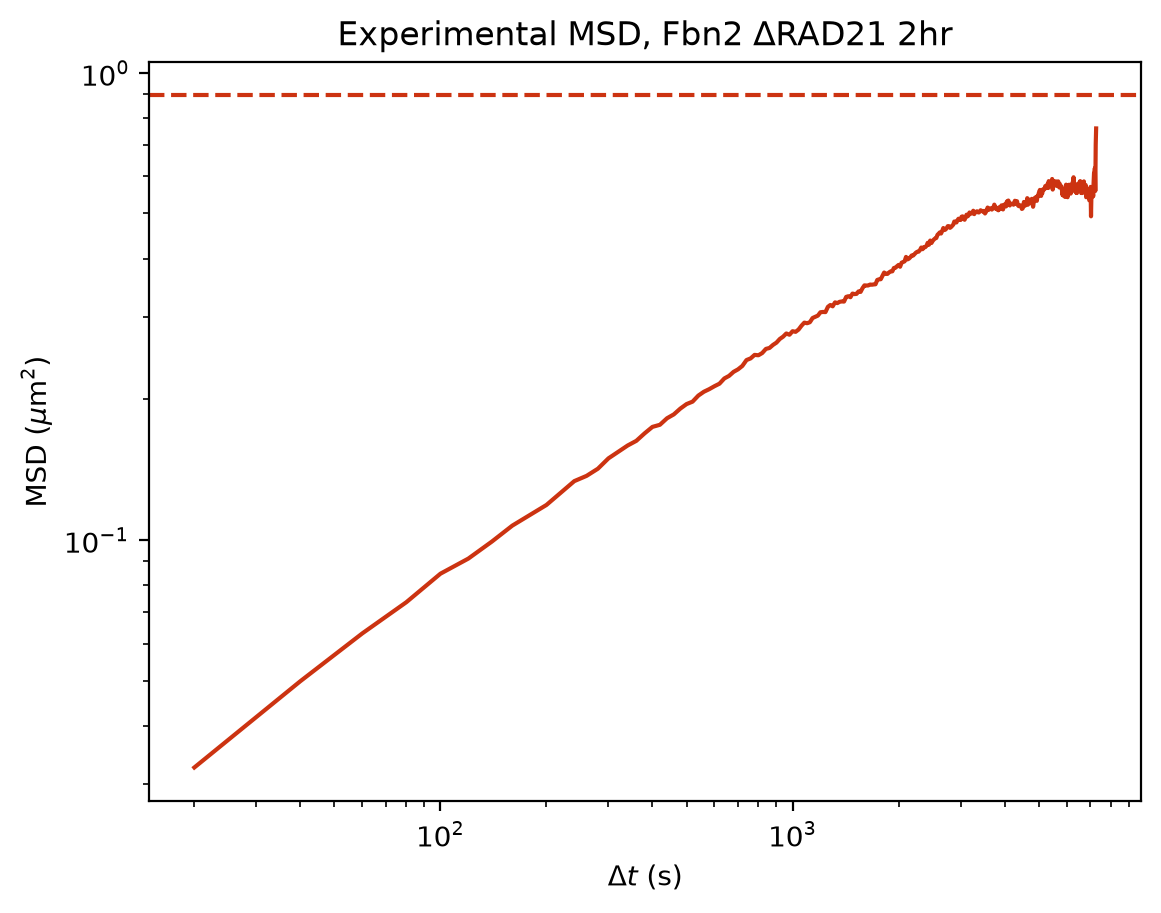

In [3]:
# Load Fbn2 trajectories (Gabriele et al. 2022)
file = '/mnt/md1/jjusuf/polysim/2022_Fbn2_full_data.h5'
data = nl.io.load.hdf5(file, 'data')
dt = 20  # time between frames, in seconds

# Calculate MSD for ∆RAD21 2hr condition
data.makeSelection(['Rad21', '2hr'], logic=all)
msd_exp = nl.analysis.MSD(data)

loc_error = 0.203  # in um
msd_exp_loc_err_corrected = msd_exp - 2*loc_error**2

# Make plot
x_exp = np.arange(1, len(msd_exp_loc_err_corrected))*dt
y_exp = msd_exp_loc_err_corrected[1:]
msd_plateau_exp = get_msd_plateau(data)

fig, ax = plt.subplots()
ax.plot(x_exp, y_exp, color='#cc3311')
ax.axhline(msd_plateau_exp, linestyle='--', color='#cc3311')
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'$\Delta t$ (s)')
plt.ylabel(r'MSD ($\mu$m$^2$)')
plt.title('Experimental MSD, Fbn2 ∆RAD21 2hr')
plt.show()


In [ ]:
# Load simulation data for condition with no loop extrusion or sticky interactions
sim_output_files = list_URIs('/mnt/md1/jjusuf/polysim/outputs/trajectory_noLEF_noEP_absquant_region_bootcamp_version')
print(f'{len(sim_output_files)} saved blocks found')

# Put in simulation parameters
region_size = 2000
chrom_size = 70000
num_regions = chrom_size // region_size
region_starts = np.arange(num_regions) * region_size  # indices at which each region starts

pos1 = 35000       # this is more or less arbitrary; just don't want to be too close to the chain ends
pos2 = pos1 + 515  # separation of Fbn2 loop anchors = 515 kb

poly_steps_per_block = 40  # copy from simulation script
saveevery = 500            # copy from simulation script
timesteps_per_save_block = poly_steps_per_block * saveevery  # how many polymer timesteps per SAVE block

# Load trajectories into a noctiluca TaggedSet
blocks_to_sample = np.arange(10_000, len(sim_output_files))
disp_vectors = np.zeros((len(blocks_to_sample), 3))
for i in tqdm.tqdm(range(len(blocks_to_sample))):
    block_num = blocks_to_sample[i]
    uri = load_URI(sim_output_files[block_num])
    block_data = uri['pos']
    disp_vectors[i,:] = block_data[pos2] - block_data[pos1]
traj_set = nl.TaggedSet()
traj_set.add(nl.Trajectory(disp_vectors))

# This may take a couple minutes to run


36000 saved blocks found


100%|██████████| 26000/26000 [02:00<00:00, 215.22it/s]


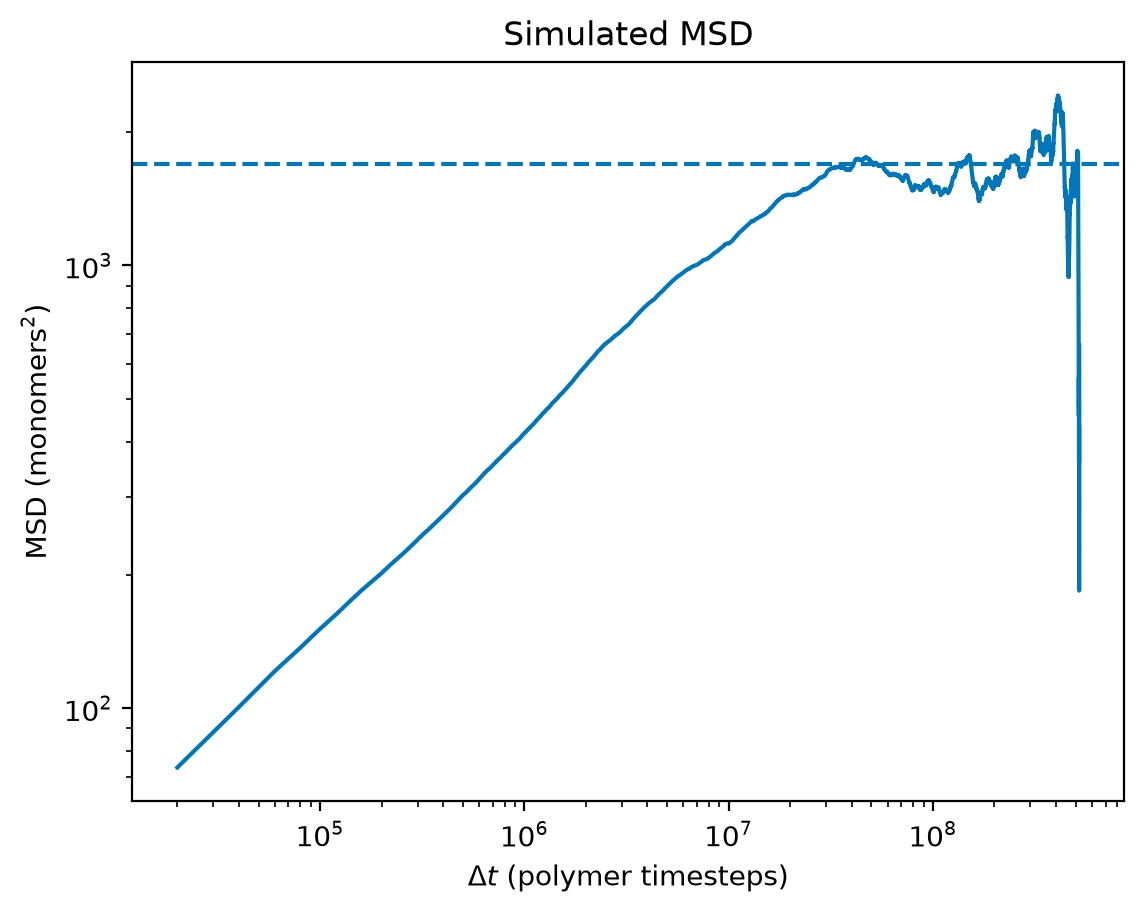

In [10]:
msd_sim = nl.analysis.MSD(traj_set)

x_sim = np.arange(1, len(msd_sim)) * timesteps_per_save_block
y_sim = msd_sim[1:]
msd_plateau_sim = get_msd_plateau(traj_set)

fig, ax = plt.subplots()
ax.plot(x_sim, y_sim, color='#0077bb')
ax.axhline(msd_plateau_sim, linestyle='--', color='#0077bb')
ax.set_xscale('log')
ax.set_yscale('log')
plt.xlabel(r'$\Delta t$ (polymer timesteps)')
plt.ylabel(r'MSD (monomers$^2$)')
plt.title('Simulated MSD')
plt.show()


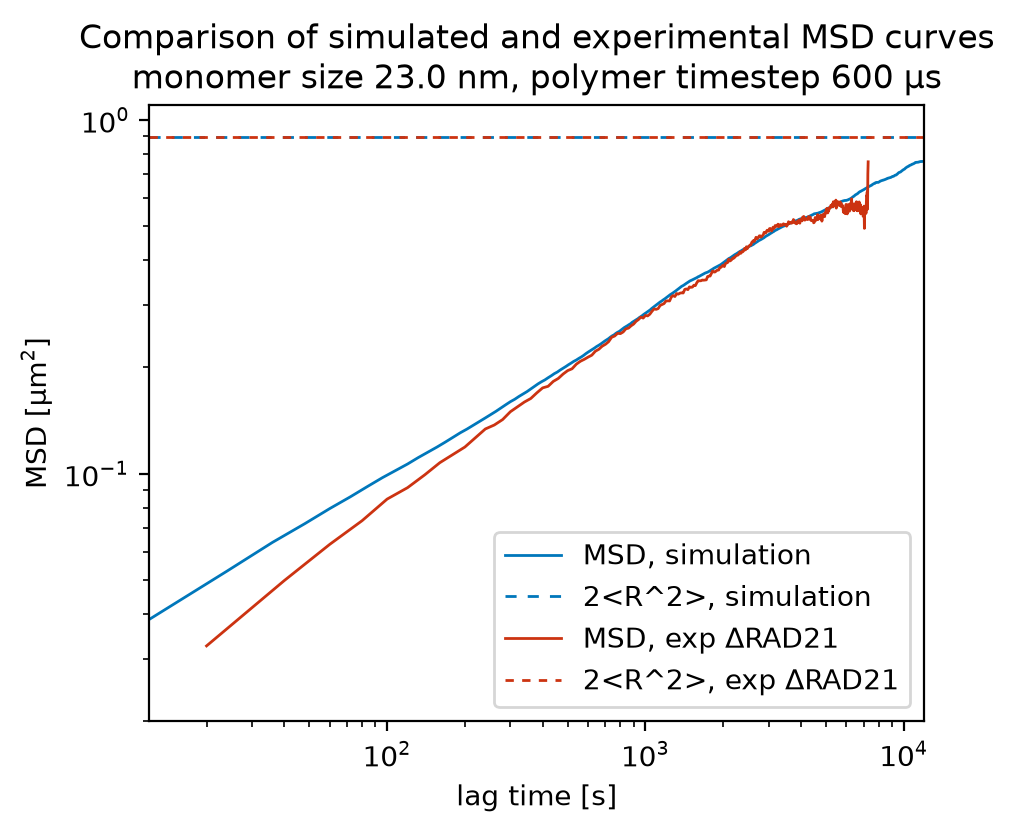

In [24]:
# Now overlay the two MSDs

monomer_size_um = np.sqrt(msd_plateau_exp/msd_plateau_sim)  # µm
sim_timestep_duration_s = 0.0006  # seconds  <-- play with this value to try to find the best fit

x_sim_real_units = x_sim * sim_timestep_duration_s
y_sim_real_units = y_sim * (monomer_size_um)**2
msd_plateau_sim_real_units = msd_plateau_sim * (monomer_size_um)**2

fig, ax = plt.subplots(figsize=(5,4))
ax.plot(x_sim_real_units, y_sim_real_units, color='#0077bb', linewidth=1)
ax.axhline(y=msd_plateau_sim_real_units, linestyle='--', color='#0077bb', linewidth=1, zorder=-1, dashes=[4,4]);
ax.plot(x_exp, y_exp, color='#cc3311', linewidth=1)
ax.axhline(y=msd_plateau_exp, linestyle='--', color='#cc3311', linewidth=1, zorder=-1, dashes=[3,3])
ax.legend(['MSD, simulation','2<R^2>, simulation','MSD, exp ∆RAD21','2<R^2>, exp ∆RAD21'])
ax.set_xlabel('lag time [s]');
ax.set_ylabel('MSD [\u03BCm$^2$]')
ax.set_title('Comparison of simulated and experimental MSD curves\n'+f'monomer size {monomer_size_um*1e3:.1f} nm, polymer timestep {sim_timestep_duration_s*1e6:.0f} \u03BCs');
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(12, 12000);
ax.set_ylim(0.02,1.1);
